# Phân tích hội tụ của Robust Risk-Aware Bandit
Notebook này nạp dữ liệu từ các file `.npz` và vẽ đồ thị chi tiết cho từng chỉ số.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import re

# 1. Cấu hình đường dẫn dữ liệu
data_dir = "results/robust_syn_d=20_a=30_pi=eps-greedy0.1_std=0.1"
n_list = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000]

color_map = {
    'robust': '#ff7f0e',        # Cam
    'quantile_risk': '#1f77b4', # Xanh dương
    'risk_lin_lcb': '#2ca02c',  # Xanh lá (Linear)
    'neural_regression': '#d62728' # Đỏ
}

def get_algo_prefixes(data_dir):
    files = glob.glob(os.path.join(data_dir, "*.npz"))
    prefixes = set()
    for f in files:
        basename = os.path.basename(f)
        match = re.match(r"^(.*?)_(robust_syn|mushroom|insulin)_", basename)
        if match:
            prefixes.add(match.group(1))
    return sorted(list(prefixes))

def load_all_algorithms(data_dir, n_list):
    prefixes = get_algo_prefixes(data_dir)
    print(f"Tìm thấy các thuật toán: {prefixes}")
    
    all_results = {}
    all_files = glob.glob(os.path.join(data_dir, "*.npz"))
    
    for prefix in prefixes:
        summary = {'n_regret': [], 'n_extra': [], 'regret_mean': [], 'regret_std': [], 
                   'subopt_mean': [], 'subopt_std': [], 'gt_cvar_mean': [], 'gt_cvar_std': [],
                   'oracle_cvar': []}
        
        for n in n_list:
            # Tìm file khớp CHÍNH XÁC prefix và n
            # Pattern: prefix + cái gì đó + _n={n} + (.npz hoặc _layers)
            target_files = []
            for f in all_files:
                fname = os.path.basename(f)
                if fname.startswith(prefix) and re.search(fr"_n={n}(_|\.npz)", fname):
                    target_files.append(f)
            
            if not target_files: continue
                
            # Load file đầu tiên tìm thấy
            d = np.load(target_files[0], allow_pickle=True)
            algo_name = d['algo_names'][0].replace(' ', '_') if 'algo_names' in d else prefix

            def get_d(s): 
                if algo_name and f"{algo_name}_{s}" in d: return d[f"{algo_name}_{s}"]
                return d[s] if s in d else None

            r = get_d('regrets')
            if r is not None:
                summary['n_regret'].append(n)
                summary['regret_mean'].append(np.mean(r))
                summary['regret_std'].append(np.std(r) / np.sqrt(len(r.flatten())))
            
            c = get_d('gt_cvars')
            if c is not None:
                summary['n_extra'].append(n)
                o_cvar = np.mean(d['oracle_cvars'])
                summary['gt_cvar_mean'].append(np.mean(c))
                summary['gt_cvar_std'].append(np.std(c) / np.sqrt(len(c.flatten())))
                sub = o_cvar - c
                summary['subopt_mean'].append(np.mean(sub))
                summary['subopt_std'].append(np.std(sub) / np.sqrt(len(c.flatten())))
                summary['oracle_cvar'].append(o_cvar)
        
        all_results[prefix] = summary
        
    return all_results

all_summaries = load_all_algorithms(data_dir, n_list)
print("Dữ liệu của tất cả thuật toán đã nạp xong!")

Tìm thấy các thuật toán: ['quantile_risk', 'risk_lin_lcb', 'robust']
Dữ liệu của tất cả thuật toán đã nạp xong!


### 1. Biểu đồ Regret (Hội tụ kỳ vọng)
Kỳ vọng phần thưởng bị mất so với Oracle.

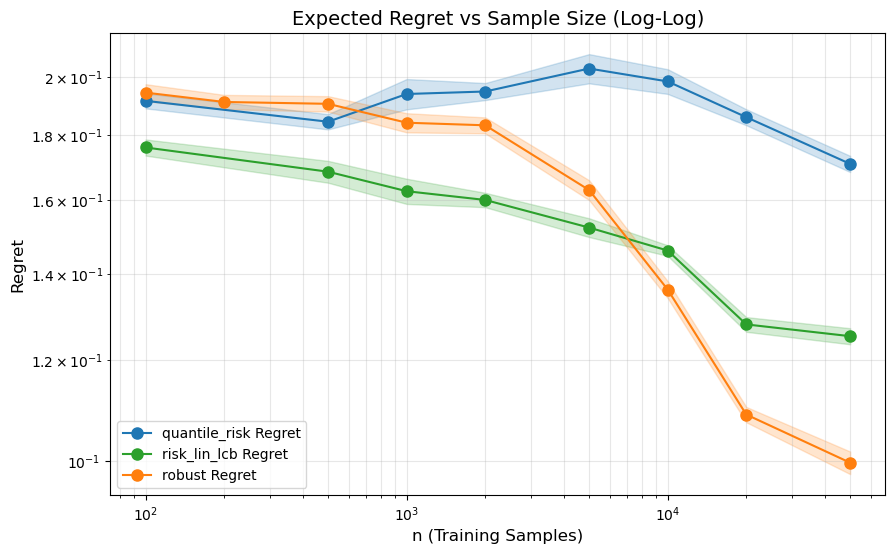

In [14]:
plt.figure(figsize=(10, 6))
for algo, summary in all_summaries.items():
    if not summary['n_regret']: continue
    color = color_map.get(algo, None)
    plt.plot(summary['n_regret'], summary['regret_mean'], '-o', label=f"{algo} Regret", markersize=8, color=color)
    plt.fill_between(summary['n_regret'], 
                     np.array(summary['regret_mean']) - np.array(summary['regret_std']), 
                     np.array(summary['regret_mean']) + np.array(summary['regret_std']), 
                     alpha=0.2, color=color)

plt.xscale('log'); plt.yscale('log')
plt.title("Expected Regret vs Sample Size (Log-Log)", fontsize=14)
plt.xlabel("n (Training Samples)", fontsize=12); plt.ylabel("Regret", fontsize=12)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

### 2. Suboptimality Gap (Hội tụ rủi ro CVaR)
Giá trị này tiến về 0 nghĩa là thuật toán học được chính sách tối ưu về mặt rủi ro. Khoảng cách được tính bằng: `Oracle CVaR - Agent CVaR`.

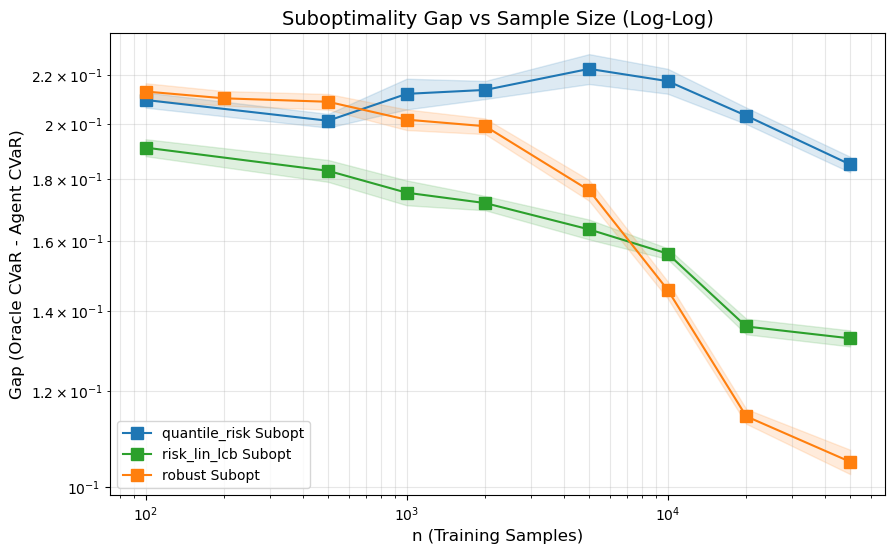

In [15]:
plt.figure(figsize=(10, 6))
for algo, summary in all_summaries.items():
    if not summary['n_extra']: continue
    color = color_map.get(algo, None)
    plt.plot(summary['n_extra'], summary['subopt_mean'], '-s', label=f"{algo} Subopt", markersize=8, color=color)
    plt.fill_between(summary['n_extra'], 
                     np.array(summary['subopt_mean']) - np.array(summary['subopt_std']), 
                     np.array(summary['subopt_mean']) + np.array(summary['subopt_std']), 
                     alpha=0.15, color=color)

plt.xscale('log'); plt.yscale('log')
plt.title("Suboptimality Gap vs Sample Size (Log-Log)", fontsize=14)
plt.xlabel("n (Training Samples)", fontsize=12); plt.ylabel("Gap (Oracle CVaR - Agent CVaR)", fontsize=12)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

### 3. So sánh Agent CVaR vs Oracle CVaR
Biểu đồ trực quan cho thấy mức độ an toàn của Agent so với giới hạn tối ưu của Oracle.

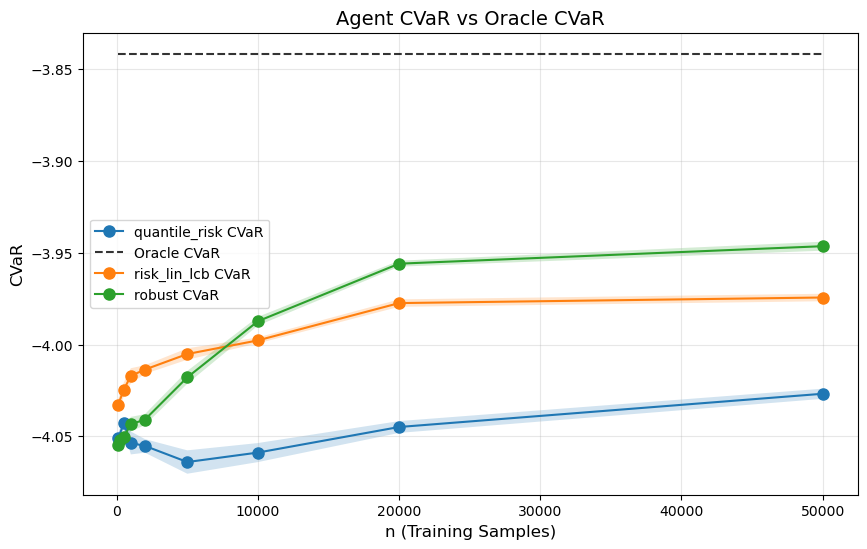

In [16]:
plt.figure(figsize=(10, 6))
first = True
for algo, summary in all_summaries.items():
    if not summary['n_extra']: continue
    plt.plot(summary['n_extra'], summary['gt_cvar_mean'], '-o', label=f"{algo} CVaR", markersize=8)
    plt.fill_between(summary['n_extra'], 
                     np.array(summary['gt_cvar_mean']) - np.array(summary['gt_cvar_std']), 
                     np.array(summary['gt_cvar_mean']) + np.array(summary['gt_cvar_std']), 
                     alpha=0.2)
    if first:
        plt.plot(summary['n_extra'], summary['oracle_cvar'], 'k--', label="Oracle CVaR", alpha=0.8)
        first = False

plt.title("Agent CVaR vs Oracle CVaR", fontsize=14)
plt.xlabel("n (Training Samples)", fontsize=12); plt.ylabel("CVaR", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()